In [1]:
import pandas as pd
df = pd.read_csv("2- tuberculosis-deaths-by-age.csv")
df.head()

,Entity,Code,Year,Deaths - Tuberculosis - Sex: Both - Age: 70+ years (Number),Deaths - Tuberculosis - Sex: Both - Age: 50-69 years (Number),Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number),Deaths - Tuberculosis - Sex: Both - Age: 5-14 years (Number),Deaths - Tuberculosis - Sex: Both - Age: Under 5 (Number)
0,Afghanistan,AFG,1990,1034,1451,1208,160,808
1,Afghanistan,AFG,1991,1036,1447,1289,170,800
2,Afghanistan,AFG,1992,1034,1443,1446,191,863
3,Afghanistan,AFG,1993,1042,1454,1575,205,979
4,Afghanistan,AFG,1994,1063,1480,1653,209,1064


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 8 columns):
 #   Column                                                         Non-Null Count  Dtype
---  ------                                                         --------------  -----
 0   Entity                                                         6840 non-null   str  
 1   Code                                                           6150 non-null   str  
 2   Year                                                           6840 non-null   int64
 3   Deaths - Tuberculosis - Sex: Both - Age: 70+ years (Number)    6840 non-null   int64
 4   Deaths - Tuberculosis - Sex: Both - Age: 50-69 years (Number)  6840 non-null   int64
 5   Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number)  6840 non-null   int64
 6   Deaths - Tuberculosis - Sex: Both - Age: 5-14 years (Number)   6840 non-null   int64
 7   Deaths - Tuberculosis - Sex: Both - Age: Under 5 (Number)      6840 non-null   int64
dtype

In [ ]:
india_rows = df[df["Entity"].astype(str).str.fullmatch("India", case=False, na=False)]
india_rows


In [ ]:
df.loc[df["Entity"].str.contains("india", case=False, na=False), "Entity"]


### Task
Create a scatterplot showing the relationship between `Age` (x-axis) and `Work_Productivity_Score` (y-axis) from the existing DataFrame `df`, using a reasonable sample size to avoid overplotting.

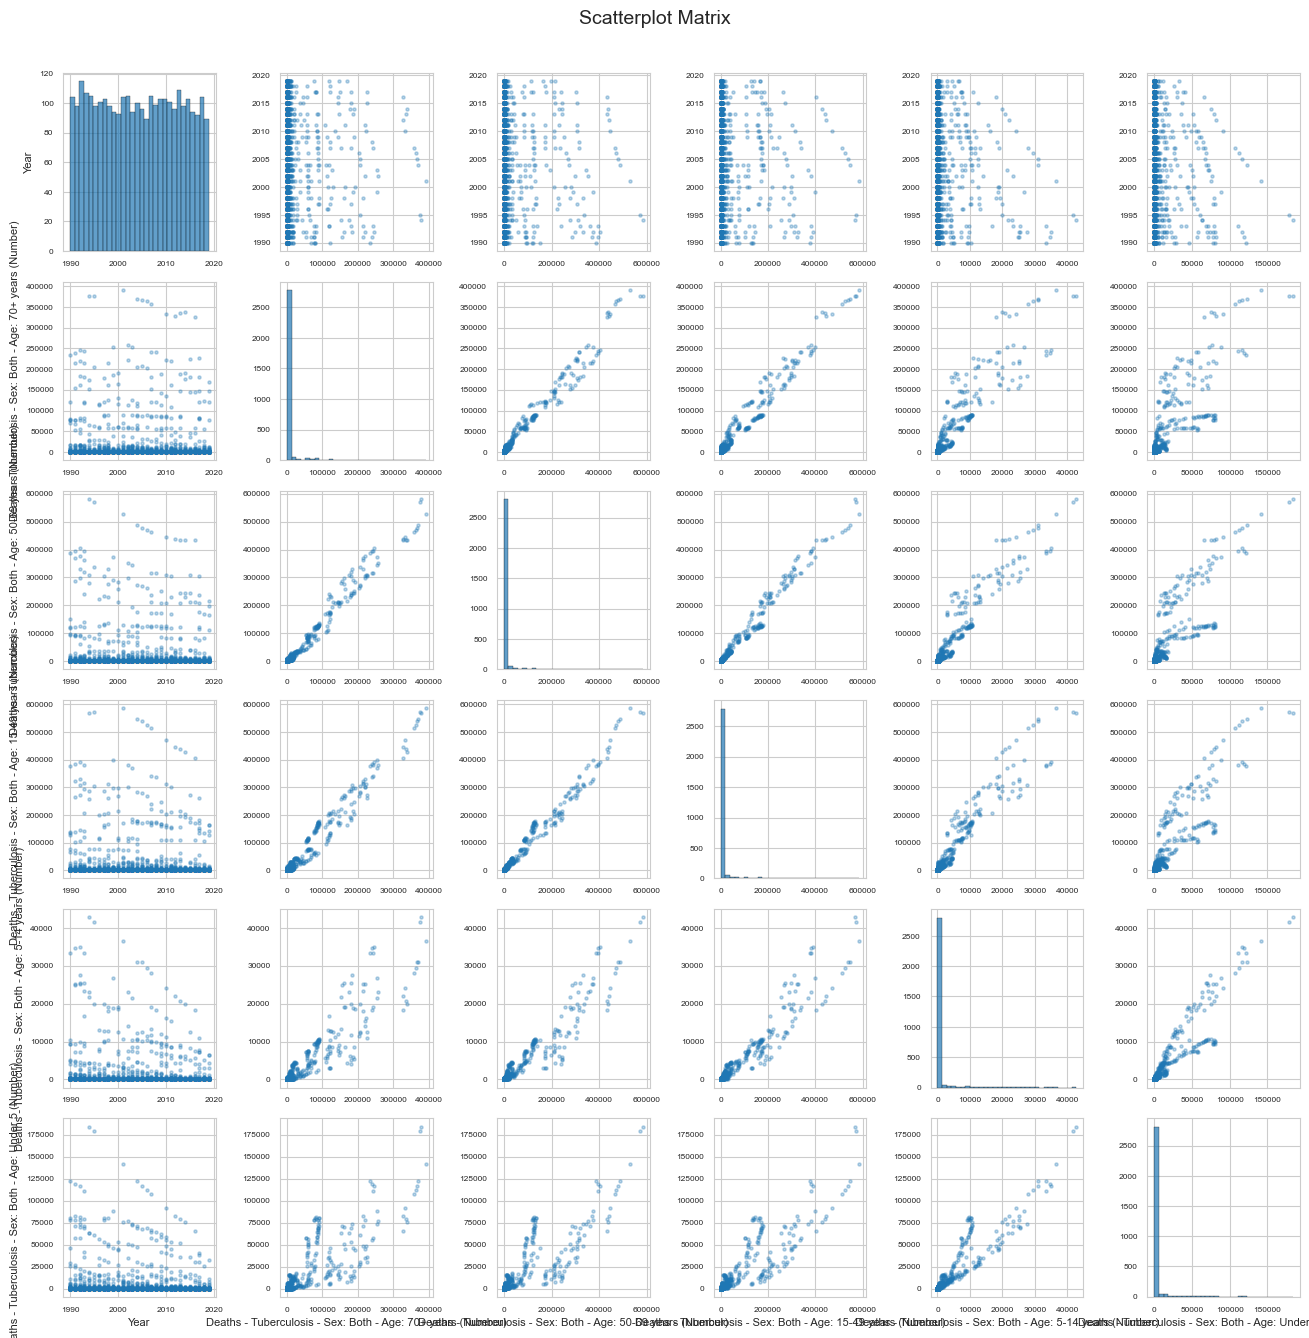

In [2]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns.tolist()
sample_df = df[numeric_cols].dropna()
n = min(3000, len(sample_df))
sample_df = sample_df.sample(n=n, random_state=42) if len(sample_df) > n else sample_df

num = len(numeric_cols)
fig, axes = plt.subplots(num, num, figsize=(max(num * 2.2, 10), max(num * 2.2, 10)))

for i, col_y in enumerate(numeric_cols):
    for j, col_x in enumerate(numeric_cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(sample_df[col_x], bins=30, alpha=0.7, edgecolor="black", linewidth=0.3)
        else:
            ax.scatter(sample_df[col_x], sample_df[col_y], s=5, alpha=0.3)
        if j == 0:
            ax.set_ylabel(col_y, fontsize=8)
        else:
            ax.set_ylabel("")
        if i == num - 1:
            ax.set_xlabel(col_x, fontsize=8)
        else:
            ax.set_xlabel("")
        ax.tick_params(labelsize=6)

fig.suptitle("Scatterplot Matrix", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [4]:
import plotly.express as px

deaths_col = "Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number)"

df_1990 = df.loc[df["Year"] == 1990, ["Code", "Year", deaths_col]].copy()

# (optional) ensure numeric in case it's read as text
df_1990[deaths_col] = df_1990[deaths_col].astype(float)

fig = px.choropleth(
    df_1990,
    locations="Code",
    color=deaths_col,
    hover_name="Code",
    color_continuous_scale="Reds",
    title="Tuberculosis deaths (Age 15–49, both sexes) in 1990",
)

fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()

In [8]:
# Case-insensitive exact match on Entity == "India"
mask = df["Entity"].astype(str).str.casefold().eq("india")
india_rows = df.loc[mask]

# Display all columns for the matching row(s)
# print(india_rows.to_string(index=False))
#
india_rows
# If you prefer a "column -> value" view (useful when it's a single row):
# print(india_rows.T)

,Entity,Code,Year,Deaths - Tuberculosis - Sex: Both - Age: 70+ years (Number),Deaths - Tuberculosis - Sex: Both - Age: 50-69 years (Number),Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number),Deaths - Tuberculosis - Sex: Both - Age: 5-14 years (Number),Deaths - Tuberculosis - Sex: Both - Age: Under 5 (Number)
2670,India,IND,1990,111356,232405,207690,16195,46353
2671,India,IND,1991,118376,241316,214299,17774,45552
2672,India,IND,1992,124100,249989,220139,18196,45090
2673,India,IND,1993,119796,239508,207833,16708,41859
2674,India,IND,1994,114937,230767,201698,14548,39159
2675,India,IND,1995,113724,223968,198257,13815,37624
2676,India,IND,1996,114784,223440,198227,13072,35016
2677,India,IND,1997,121275,232022,205083,12735,32782
2678,India,IND,1998,125537,228998,207254,12657,30737
2679,India,IND,1999,125919,218386,216772,12540,29053


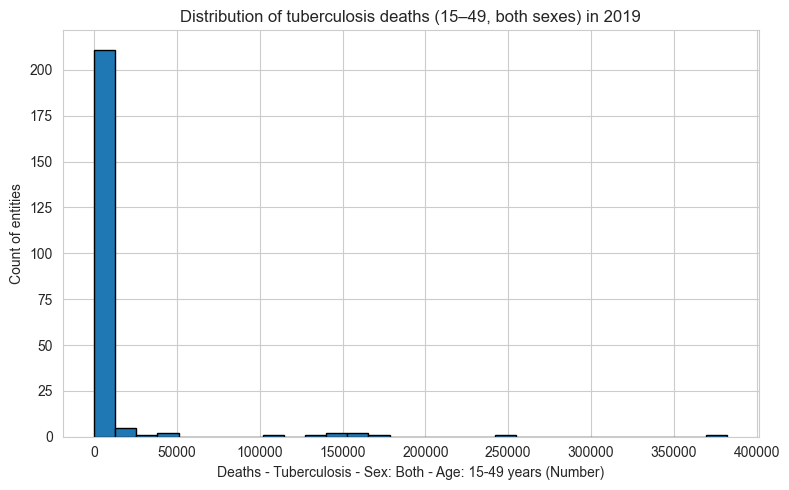

In [9]:
import matplotlib.pyplot as plt

deaths_col = "Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number)"

df_2019 = df.loc[df["Year"] == 2019, ["Entity", deaths_col]].copy()
df_2019[deaths_col] = df_2019[deaths_col].astype(float)

plt.figure(figsize=(8, 5))
plt.hist(df_2019[deaths_col].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of tuberculosis deaths (15–49, both sexes) in 2019")
plt.xlabel(deaths_col)
plt.ylabel("Count of entities")
plt.tight_layout()
plt.show()

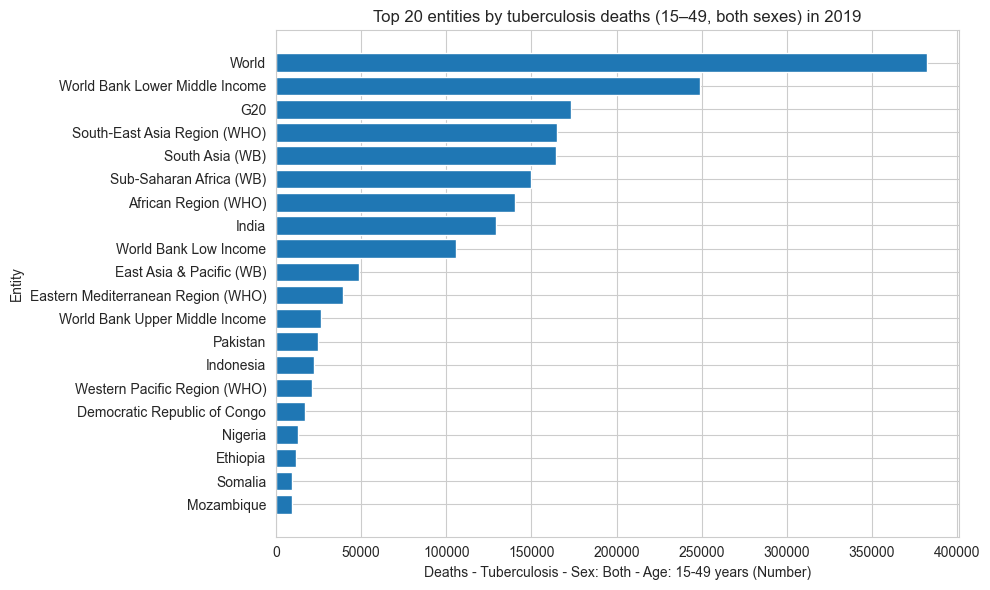

In [10]:
import matplotlib.pyplot as plt

deaths_col = "Deaths - Tuberculosis - Sex: Both - Age: 15-49 years (Number)"

df_2019 = df.loc[df["Year"] == 2019, ["Entity", deaths_col]].copy()
df_2019[deaths_col] = df_2019[deaths_col].astype(float)

top = df_2019.sort_values(deaths_col, ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["Entity"], top[deaths_col])
plt.gca().invert_yaxis()
plt.title("Top 20 entities by tuberculosis deaths (15–49, both sexes) in 2019")
plt.xlabel(deaths_col)
plt.ylabel("Entity")
plt.tight_layout()
plt.show()